In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

tmin = -.5
tmax=2.0
fmin=0.5
fmax = 16
sfreq = 32

paradigm = MotorImagery(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax,  n_classes=4)
dataset = BNCI2014001()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

Choosing from all possible events


Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
48 matching events found
No baseline correction applied
Not setting metadata
576 matching events found
No baseline correction applie

In [3]:
epochs

Number of events,288
Events,feet: 72left_hand: 72right_hand: 72tongue: 72
Time range,1.500 – 3.969 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,session_T,run_0
1,1,session_T,run_0
2,1,session_T,run_0
3,1,session_T,run_0
4,1,session_T,run_0
...,...,...,...
283,1,session_T,run_5
284,1,session_T,run_5
285,1,session_T,run_5
286,1,session_T,run_5


No projector specified for this dataset. Please consider the method self.add_proj.


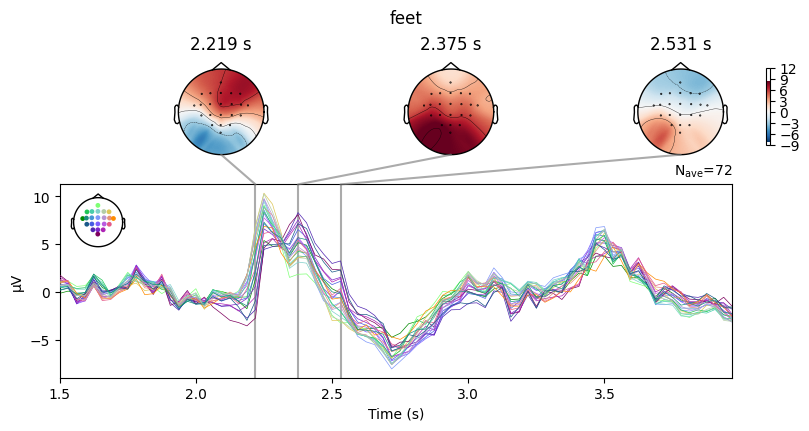

No projector specified for this dataset. Please consider the method self.add_proj.


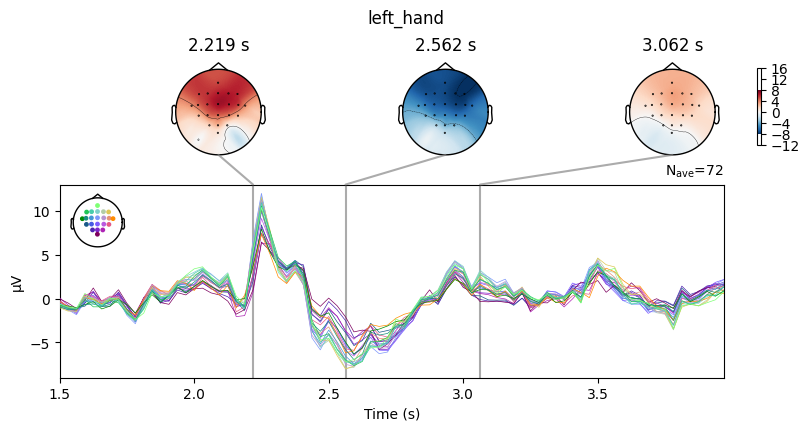

No projector specified for this dataset. Please consider the method self.add_proj.


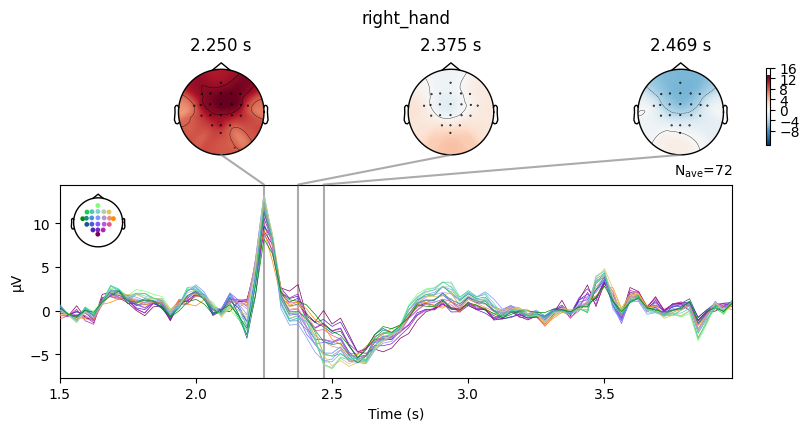

No projector specified for this dataset. Please consider the method self.add_proj.


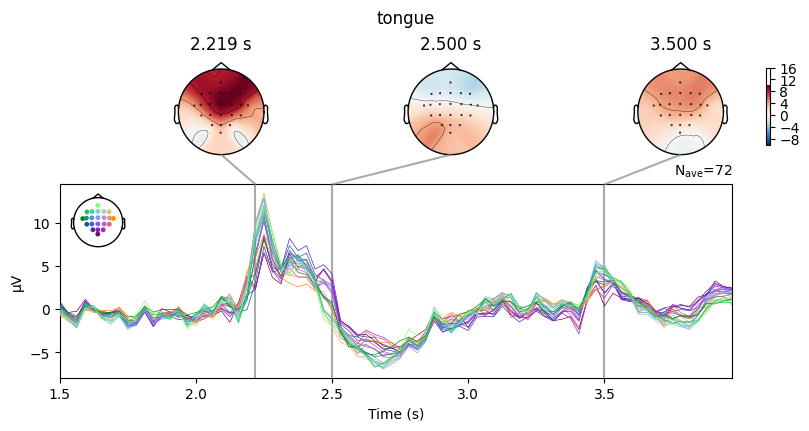

In [5]:
import numpy as np
ts_args=dict()
joint_args=dict(ts_args=ts_args)
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_3588/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(288, 22, 80)

In [59]:
from hoda.hoda import HODA, f_multiway
from hoda.gpu_opt import center
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues

hoda = HODA(
            rank=None,
            max_iter=256,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=(1,),
            taper=False,
            obj='tr',
            solver='lanczos',
            keep_train_info=True,
            verbose=True,
            prune=True,
        )
hoda.fit(X,y)

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank [3, 1] ...


HODA(keep_train_info=True, max_iter=256, obj='tr', toeplitz=(1,), tol=1e-08,
     verbose=True)

In [ ]:
hoda.train_info_

/tmp/ipykernel_3588/1487127664.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[2].set_ylim([0,None])


Error in callback <function _draw_all_if_interactive at 0x7f81de7c3010> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 640x480 with 4 Axes>

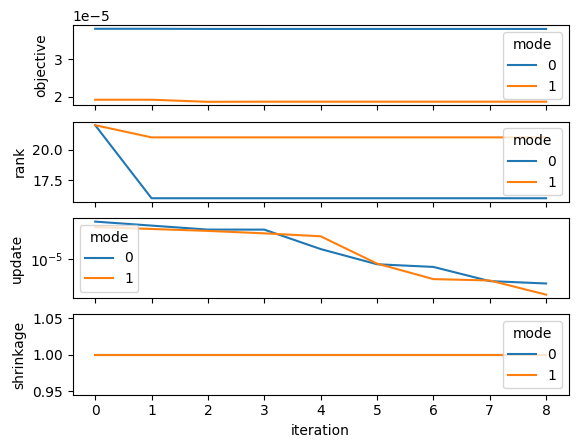

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_, x='iteration', y='F', ax=axs[0])
    axs[1].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='p', ax=axs[1])
    axs[1].set(yscale='log')
    sns.lineplot(data=hoda.train_info_, x='iteration', y='mse', ax=axs[2])
    axs[2].set(yscale="log")
    axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")


    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='shrinkage',hue='mode', ax=axs[3])

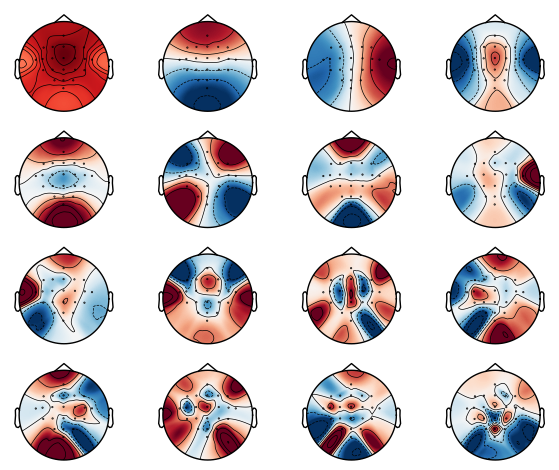

In [48]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

if len(epochs.ch_names)>1:
    n_col = col_wrap
    n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col, layout='tight')
    for i in range(hoda.rank_[0]):
        w = tl.to_numpy(hoda.scalings_[0][:,i])
        plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)


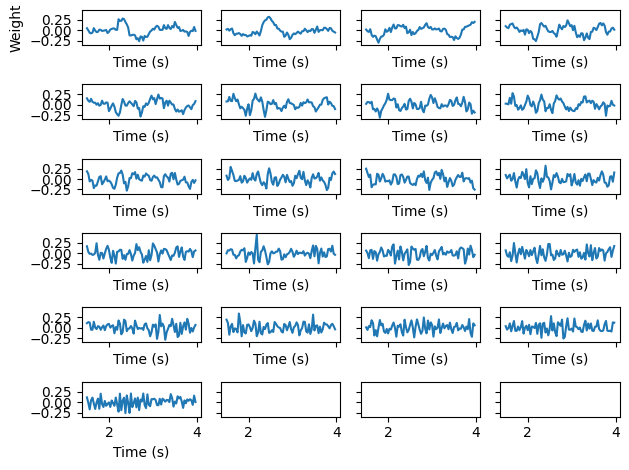

In [49]:
n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


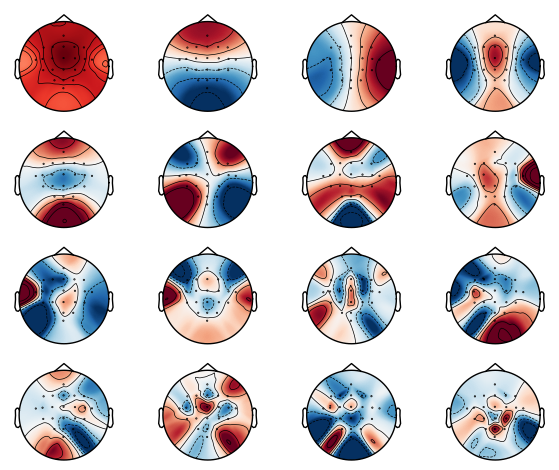

In [50]:
if len(epochs.ch_names)>1:
    
    n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col, layout='tight')
    A = hoda.aps_[0]
    for i in range(hoda.rank_[0]):
        a = tl.to_numpy(A[:,i])
        plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)



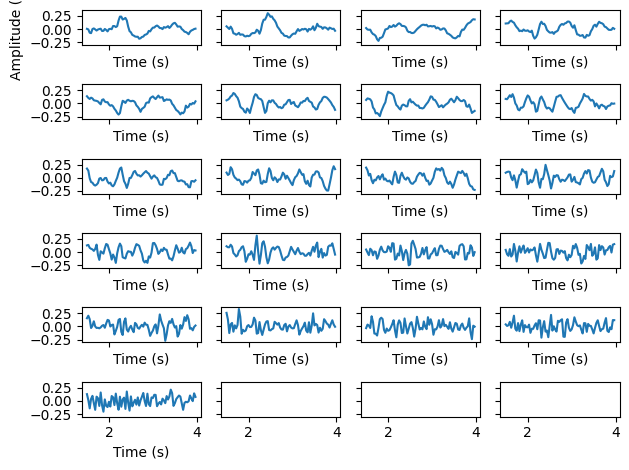

In [51]:

n_row = int(np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_[1]):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

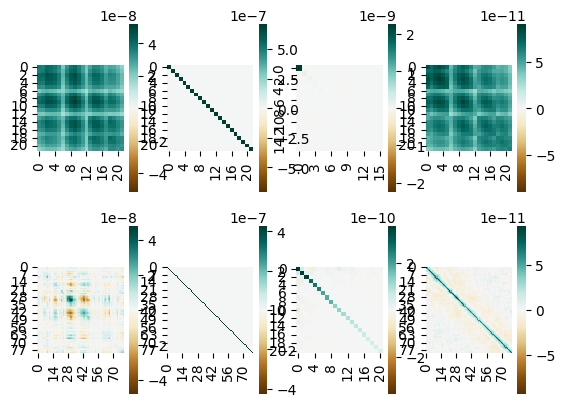

In [52]:
_, axs = plt.subplots(2,4,)
for k in range(2):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov_w=  tl.to_numpy(hoda.cov_w_[k])
    vmax = np.max(np.abs(cov_w))
    sns.heatmap(cov_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [53]:
Xt = hoda.transform(X)

In [54]:
X.shape

(288, 22, 80)

[5.21686622e-16 1.13323300e-25 4.32727022e-23 3.04998290e-19
 1.03193718e-21 2.33412179e-25 2.47184562e-23 3.72060054e-12
 5.97761531e-14 3.75802413e-05 9.11069584e-05 9.68221044e-14
 8.95051965e-10 2.07762346e-07 2.09433610e-07 1.76728169e-03]
[1.51142166e-21 1.85607010e-44 1.99676772e-06 1.55744378e-16
 6.06546590e-16 9.33115083e-09 6.73503006e-08 5.00596681e-10
 1.14943420e-04 1.00358741e-10 3.90524352e-08 1.61979519e-07
 1.08456191e-07 6.05735414e-15 2.30634975e-11 9.46081186e-12
 4.48790659e-09 1.22576029e-12 2.73872371e-04 1.00003125e-03
 2.71594673e-05]


<BarContainer object of 16 artists>

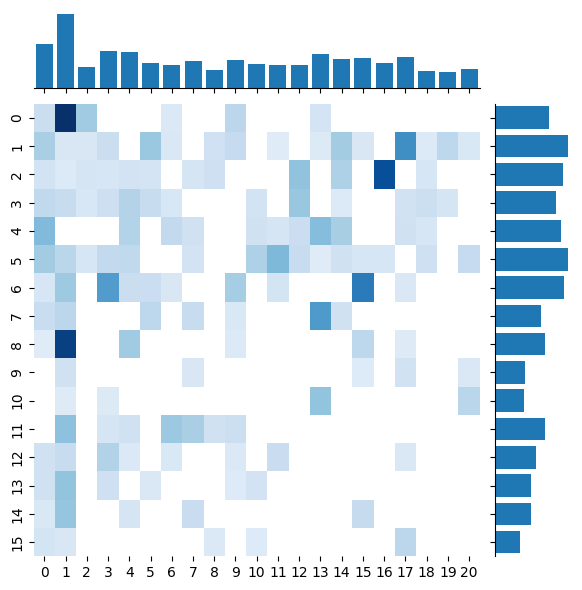

In [55]:
from hoda.hoda import f_multiway
from hoda.gpu_opt import combine_pvalues

snr,p = f_multiway(X,y)
F, p = f_oneway(Xt,y)


Xsq_sp, p_sp = combine_pvalues(p, axis=(1,))
Xsq_tmp, p_tmp = combine_pvalues(p, axis=(0,))
print(p_sp)
print(p_tmp)

Xsq_sp = tl.to_numpy(Xsq_sp)
Xsq_tmp = tl.to_numpy(Xsq_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, Xsq_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, Xsq_sp)

<Axes: xlabel='0', ylabel='1'>

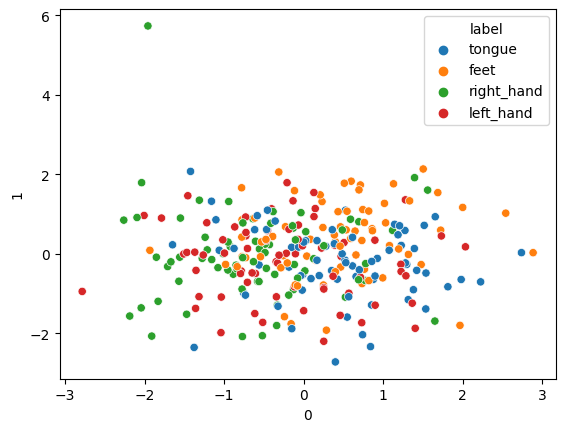

In [56]:
import pandas as pd
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

X_viz = X.reshape((X.shape[0],-1))
Xt_viz = Xt.reshape((Xt.shape[0],-1))
n_components = 2
decomp  = PCA(n_components=n_components, whiten=True)
X_viz = decomp.fit_transform(tl.to_numpy(X_viz))
Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_viz))

df = pd.DataFrame(Xt_viz)
df['label'] = labels
sns.scatterplot(data=df, x=0, y=1, hue='label')

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_3588/3696127509.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


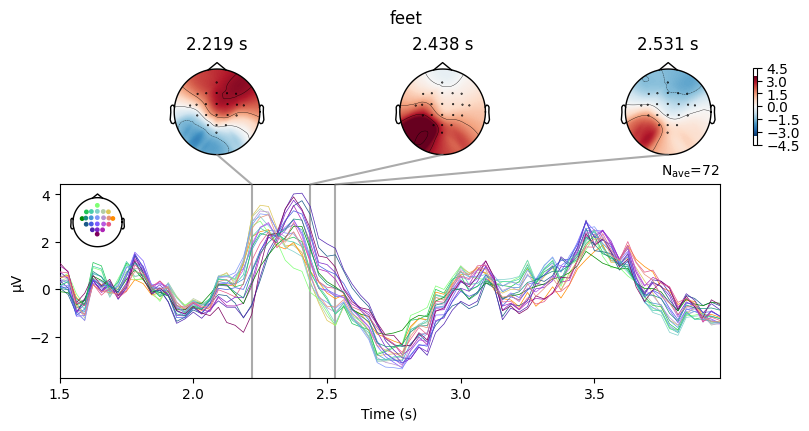

No projector specified for this dataset. Please consider the method self.add_proj.


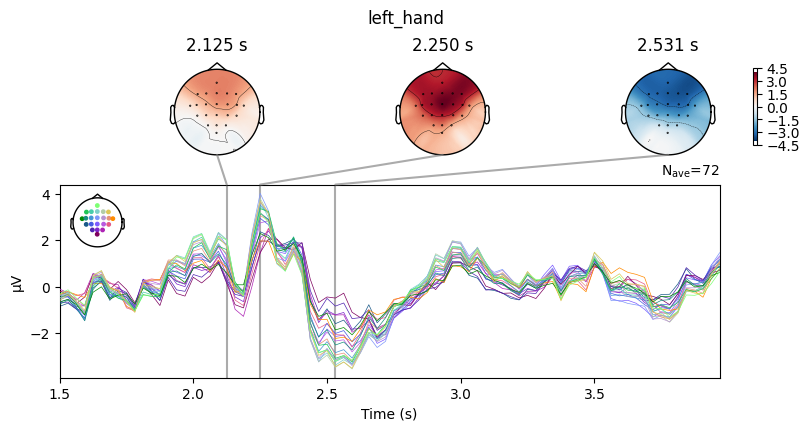

No projector specified for this dataset. Please consider the method self.add_proj.


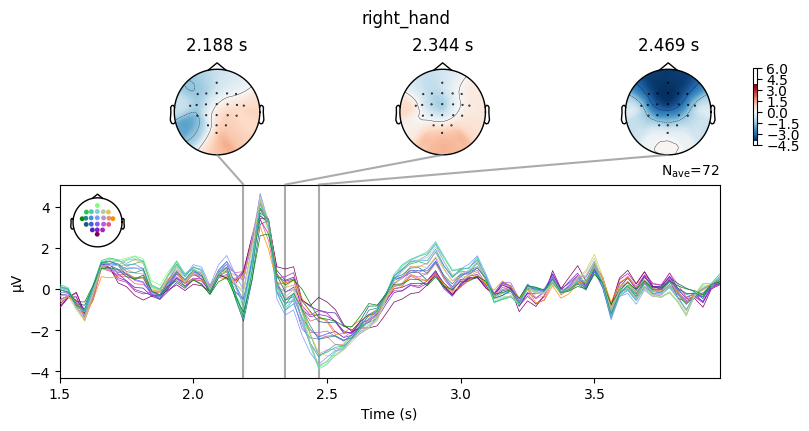

No projector specified for this dataset. Please consider the method self.add_proj.


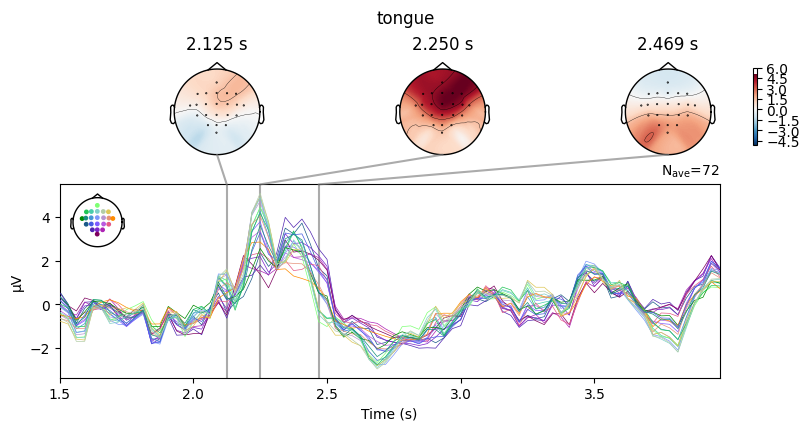

In [57]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))

for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls, **joint_args)
    else:
        evoked_rec.plot(**ts_args)

## Classification

In [58]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
Xt_flat = StandardScaler().fit_transform(Xt_flat)
clf = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
clf.fit(Xt_flat, y)
score_proba = clf.predict_proba(Xt_flat)
print(roc_auc_score(y,score_proba, multi_class='ovo'))

0.999630272633745
